In [ ]:
# Import pandas: essential library for data manipulation and analysis using DataFrames
import pandas as pd
# Import numpy: provides numerical computing capabilities and array operations
import numpy as np
# Import matplotlib.pyplot: plotting library for creating visualizations (aliased as plt)
import matplotlib.pyplot as plt
# Import seaborn: high-level statistical visualization library built on matplotlib (aliased as sns)
import seaborn as sns

# Apply seaborn's default styling to all matplotlib plots for improved aesthetics
sns.set()

# Load the Excel file into a pandas DataFrame named 'df'
# The file contains chocolate sales data with product, sales, and location information
df = pd.read_excel("Chocolate_Sales_EDA.xlsx")
# Display the first 5 rows of the DataFrame to preview the data structure and columns
df.head()

,Date,Country,Product,Sales Person,Boxes Shipped,Amount
0,2024-11-24,USA,Dark Chocolate,Omar,83,1162
1,2024-08-19,Germany,Caramel Bar,Lina,137,2603
2,2024-02-13,UK,Dark Chocolate,Omar,48,240
3,2024-07-28,Canada,White Chocolate,Omar,65,1040
4,2024-10-08,UK,Milk Chocolate,Hassan,171,2052


In [ ]:
# Check the dimensions (shape) of the DataFrame
# Returns (number_of_rows, number_of_columns) to understand dataset size
print("Shape:", df.shape)

Shape: (300, 6)


In [ ]:
# Check for missing values (NaN/null) in each column
# Returns a count of missing values per column to assess data quality
df.isna().sum()

Date             0
Country          0
Product          0
Sales Person     0
Boxes Shipped    0
Amount           0
dtype: int64

In [ ]:
# Check for duplicate rows in the entire DataFrame
# Identifies if there are any completely identical rows (data quality check)
df.duplicated().sum()

np.int64(0)

In [ ]:
# Generate descriptive statistics for all numerical columns in the DataFrame
# Includes count, mean, std, min, 25%, 50%, 75%, and max values
# This provides a comprehensive summary of the data distribution and central tendencies
df.describe()

,Date,Boxes Shipped,Amount
count,300,300.000000,300.000000
mean,2024-07-12 04:19:12,104.616667,1331.110000
min,2024-01-01 00:00:00,1.000000,9.000000
25%,2024-04-13 18:00:00,58.000000,617.500000
50%,2024-07-22 12:00:00,103.500000,1137.000000
75%,2024-10-11 06:00:00,154.250000,1971.750000
max,2024-12-28 00:00:00,200.000000,4000.000000
std,NaN,56.348857,902.997015


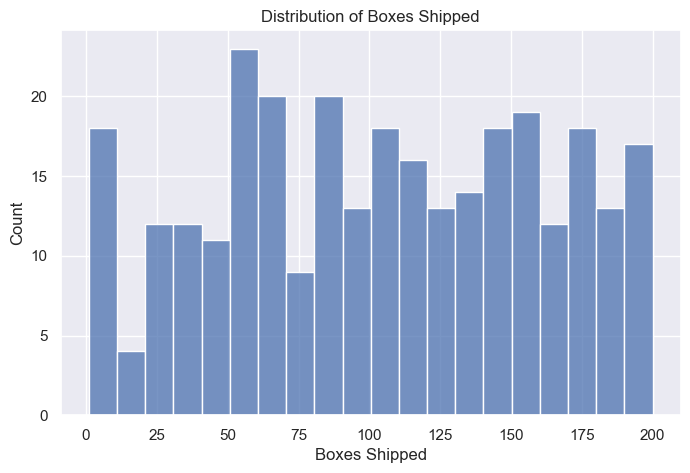

In [ ]:
# Create a histogram visualization of the "Boxes Shipped" column
# Set figure size to 8 inches wide and 5 inches tall for better visibility
plt.figure(figsize=(8,5))
# Use seaborn's histplot with 20 bins to show the distribution of boxes shipped
# Histplot is useful for understanding the frequency distribution of a continuous variable
sns.histplot(df["Boxes Shipped"], bins=20)
# Add a descriptive title to the histogram
plt.title("Distribution of Boxes Shipped")
# Display the plot
plt.show()

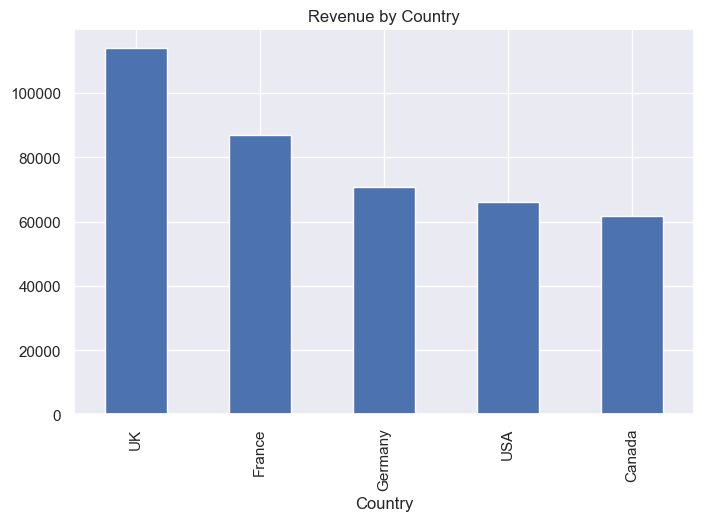

Country
UK         114065
France      86950
Germany     70668
USA         66046
Canada      61604
Name: Amount, dtype: int64

In [ ]:
# Group sales data by country and sum the "Amount" (revenue) for each country
# sort_values(ascending=False) arranges countries from highest to lowest revenue
country_revenue = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

# Create a new figure with dimensions 8x5 inches for the bar chart
plt.figure(figsize=(8,5))
# Create a horizontal bar chart showing revenue contribution by each country
# kind="bar" creates vertical bars for each country
country_revenue.plot(kind="bar")
# Add a descriptive title to indicate what the chart displays
plt.title("Revenue by Country")
# Display the visualization
plt.show()

# Display the numerical values of revenue by country for reference
country_revenue

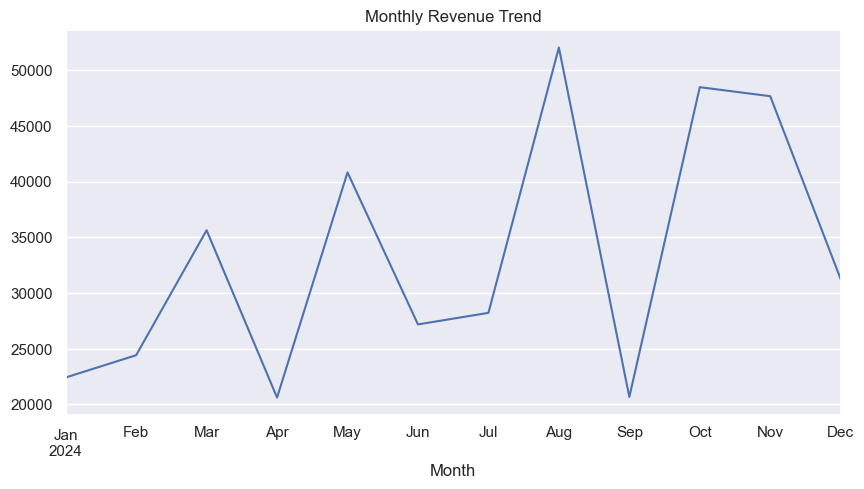

Month
2024-01    22414
2024-02    24412
2024-03    35627
2024-04    20612
2024-05    40820
2024-06    27175
2024-07    28214
2024-08    52025
2024-09    20667
2024-10    48469
2024-11    47659
2024-12    31239
Freq: M, Name: Amount, dtype: int64

In [ ]:
# Convert the "Date" column to Year-Month period format and store as a new column
# This groups dates by month, allowing for monthly aggregation analysis
df["Month"] = df["Date"].dt.to_period("M")

# Group sales data by month and sum the "Amount" (revenue) for each month
# Creates a time series showing total monthly revenue
monthly_revenue = df.groupby("Month")["Amount"].sum()

# Create a new figure with dimensions 10x5 inches for better visualization of trends
plt.figure(figsize=(10,5))
# Plot monthly revenue as a line chart to show trends over time
# Line charts are ideal for visualizing temporal patterns and trends
monthly_revenue.plot()
# Add a descriptive title to indicate the monthly revenue progression
plt.title("Monthly Revenue Trend")
# Display the visualization
plt.show()

# Display the actual monthly revenue values for detailed reference and analysis
monthly_revenue